# EMiF Class 12 - Regime changes, structural breaks and Markowitz portfolios

This notebook supports the empirical application at the end of the slide deck.

Objective: use S&P 500, Gold, US investment-grade bonds and US high-yield bonds to show that a change in the equity-bond correlation regime changes the optimal Markowitz allocation.

The notebook intentionally keeps the implementation simple:

1. compute weekly log returns;
2. measure the 52-week rolling correlation between S&P 500 and US IG bonds;
3. estimate a two-state Markov-switching model on that correlation;
4. estimate Bai-Perron-style break dates with a simple dynamic-programming algorithm;
5. compare long-only Markowitz portfolios across regimes and break segments.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 1. Load the data

The first column is the date, so we load it as the index. The data are daily total return indices / price series for four assets.

In [2]:
data_path = 'data/Data_regimes.xlsx'

prices = pd.read_excel(data_path, index_col=0, parse_dates=True)
prices = prices.ffill().dropna()
prices = prices[['S&P500', 'Gold', 'US IG Bonds', 'US HY Bonds']]

weekly_prices = prices.resample('W-FRI').last().dropna()
weekly_returns = np.log(weekly_prices).diff().dropna()
assets = list(weekly_returns.columns)

print(prices.index.min(), prices.index.max())
weekly_returns.head()

1990-01-02 00:00:00 2026-04-24 00:00:00


,S&P500,Gold,US IG Bonds,US HY Bonds
1990-01-12,-0.035,0.027,-0.002,-0.001
1990-01-19,-0.002,-0.018,-0.007,0.000
1990-01-26,-0.040,0.023,-0.006,-0.004
1990-02-02,0.016,-0.000,0.001,-0.019
1990-02-09,0.008,-0.006,0.003,-0.000


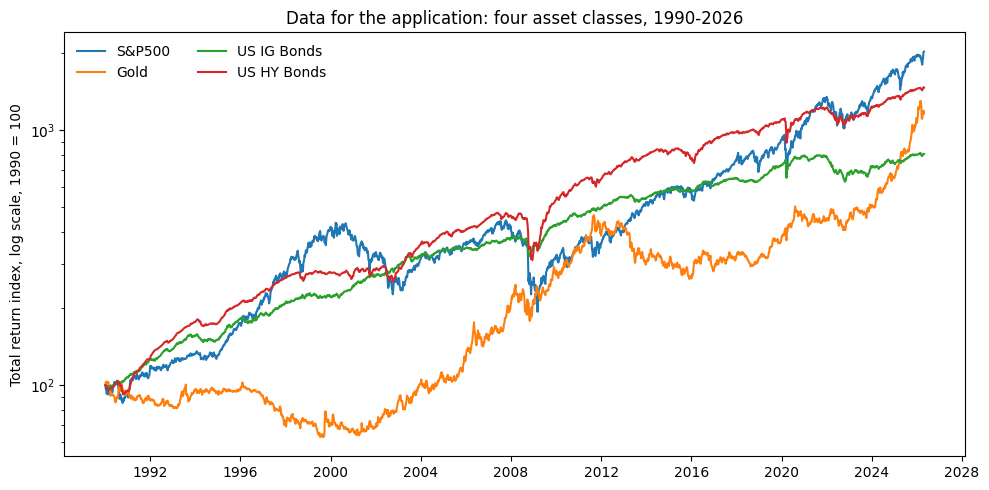

In [3]:
norm = weekly_prices / weekly_prices.iloc[0] * 100

plt.figure(figsize=(10, 5))
for col in norm.columns:
    plt.plot(norm.index, norm[col], label=col, linewidth=1.5)
plt.yscale('log')
plt.title('Data for the application: four asset classes, 1990-2026')
plt.ylabel('Total return index, log scale, 1990 = 100')
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.savefig('Figures/application_asset_universe.png', dpi=200)
plt.show()

## 2. Observable object: the equity-bond correlation

We use the 52-week rolling correlation between S&P 500 returns and US IG bond returns as a simple proxy for the diversification regime.

A negative or low correlation means bonds diversify equity risk. A high positive correlation means the main building blocks of a standard multi-asset portfolio become less diversifying.

In [4]:
rolling_corr = weekly_returns['S&P500'].rolling(52).corr(weekly_returns['US IG Bonds']).dropna()
rolling_corr.describe()

count   1,843.000
mean        0.075
std         0.319
min        -0.625
25%        -0.187
50%         0.062
75%         0.323
max         0.736
dtype: float64

## 3. Markov-switching model on the correlation

We estimate:

$$
 c_t = \mu_{s_t} + \sigma_{s_t}\varepsilon_t, \qquad s_t \in \{0,1\},
$$

with transition probabilities:

$$
 p_{ij} = \mathbb{P}(s_t=j \mid s_{t-1}=i).
$$

The state is latent. The Hamilton filter gives the probability of being in each state at each date.

In [5]:
ms_model = sm.tsa.MarkovRegression(
    rolling_corr,
    k_regimes=2,
    trend='c',
    switching_variance=True
)

ms_result = ms_model.fit(disp=False, maxiter=300)
print(ms_result.summary())

                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                 1843
Model:               MarkovRegression   Log Likelihood                 543.538
Date:                Sun, 03 May 2026   AIC                          -1075.077
Time:                        09:33:48   BIC                          -1041.962
Sample:                    01-04-1991   HQIC                         -1062.867
                         - 04-24-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1993      0.006    -34.613      0.000      -0.211      -0.188
sigma2         0.0227      0.001     19.413      0.0

In [6]:
probs = ms_result.smoothed_marginal_probabilities
state_means = [(rolling_corr * probs[s]).sum() / probs[s].sum() for s in [0, 1]]
high_state = int(np.argmax(state_means))
low_state = 1 - high_state
high_prob = probs[high_state]
state_high = (high_prob > 0.5).astype(int)

print('Average correlation in state 0:', state_means[0])
print('Average correlation in state 1:', state_means[1])
print('High-correlation state:', high_state)

Average correlation in state 0: -0.19931121011093017
Average correlation in state 1: 0.33120680313497636
High-correlation state: 1


## 4. Structural breaks in the correlation

We now estimate break dates in the mean of the same rolling correlation. The model is:

$$
 c_t = \mu_j + u_t \quad \text{for } T_{j-1}<t\leq T_j.
$$

For a fixed number of breaks, the objective is to find the partition that minimizes total residual sum of squares:

$$
 (\widehat T_1,\ldots,\widehat T_m)
 = \arg\min_{T_1,\ldots,T_m} \sum_{j=1}^{m+1}\sum_{t=T_{j-1}+1}^{T_j}(c_t-\widehat\mu_j)^2.
$$

The code below implements the same dynamic-programming idea as Bai and Perron in a very simple mean-break case.

In [7]:
y = rolling_corr.values
T = len(y)
min_size = 52
n_breaks = 3

cs = np.r_[0, np.cumsum(y)]
cs2 = np.r_[0, np.cumsum(y * y)]

def segment_sse(i, j):
    n = j - i
    if n <= 0:
        return np.inf
    sy = cs[j] - cs[i]
    sy2 = cs2[j] - cs2[i]
    return sy2 - sy * sy / n

dp = [None] * (n_breaks + 2)
prev = [None] * (n_breaks + 2)

for segs in range(1, n_breaks + 2):
    d = np.full(T + 1, np.inf)
    p = np.full(T + 1, -1, dtype=int)
    if segs == 1:
        for j in range(min_size, T + 1):
            d[j] = segment_sse(0, j)
    else:
        for j in range(segs * min_size, T + 1):
            best = np.inf
            best_i = -1
            for i in range((segs - 1) * min_size, j - min_size + 1):
                value = dp[segs - 1][i] + segment_sse(i, j)
                if value < best:
                    best = value
                    best_i = i
            d[j] = best
            p[j] = best_i
    dp[segs] = d
    prev[segs] = p

break_idx = []
j = T
for segs in range(n_breaks + 1, 1, -1):
    i = prev[segs][j]
    break_idx.append(i)
    j = i

break_idx = break_idx[::-1]
break_dates = [rolling_corr.index[i] for i in break_idx]
[d.strftime('%Y-%m-%d') for d in break_dates]

['1998-01-16', '2001-04-13', '2020-03-13']

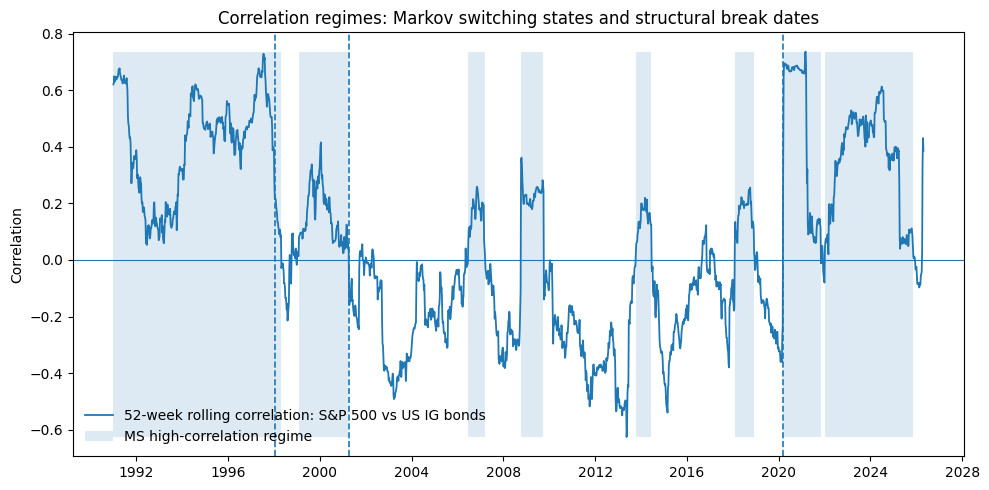

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(rolling_corr.index, rolling_corr, label='52-week rolling correlation: S&P 500 vs US IG bonds', linewidth=1.3)
plt.fill_between(high_prob.index, rolling_corr.min(), rolling_corr.max(), where=(high_prob > 0.5), alpha=0.15, label='MS high-correlation regime')
for d in break_dates:
    plt.axvline(d, linestyle='--', linewidth=1.2)
plt.axhline(0, linewidth=0.8)
plt.title('Correlation regimes: Markov switching states and structural break dates')
plt.ylabel('Correlation')
plt.legend(frameon=False, loc='lower left')
plt.tight_layout()
plt.savefig('Figures/application_correlation_regimes.png', dpi=200)
plt.show()

## 5. Markowitz portfolio in each regime

We use a standard long-only Markowitz problem:

$$
\min_w w'\Sigma_s w
$$

subject to:

$$
\iota'w=1, \qquad \mu'w = \mu^*, \qquad 0\leq w_i\leq 70\%.
$$

To isolate the effect of correlation and volatility regimes, the expected return vector is kept constant across regimes and estimated from the full sample. Only the covariance matrix changes across states.

In [9]:
mu = weekly_returns.mean() * 52
mu

S&P500        0.083
Gold          0.067
US IG Bonds   0.057
US HY Bonds   0.074
dtype: float64

In [10]:
def target_variance_portfolio(cov, target=0.07, max_weight=0.70):
    n = len(mu)
    x0 = np.ones(n) / n
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'eq', 'fun': lambda w: float(mu.values @ w) - target},
    ]
    bounds = [(0.0, max_weight)] * n
    result = minimize(
        lambda w: float(w @ cov.values @ w),
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    if not result.success:
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
        result = minimize(
            lambda w: float(w @ cov.values @ w),
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
    return pd.Series(result.x, index=assets)

state_high = state_high.reindex(weekly_returns.index).dropna()
returns_state_sample = weekly_returns.loc[state_high.index]

ms_weights = pd.DataFrame(index=assets)
regime_summary = []

for label, mask in {
    'Diversifying correlation': state_high == 0,
    'High-correlation regime': state_high == 1,
}.items():
    r = returns_state_sample.loc[mask]
    cov = r.cov() * 52
    w = target_variance_portfolio(cov)
    ms_weights[label] = w
    regime_summary.append({
        'Regime': label,
        'Observations': int(mask.sum()),
        'SPX-IG correlation': r['S&P500'].corr(r['US IG Bonds']),
        'Portfolio volatility': np.sqrt(w.values @ cov.values @ w.values),
        'SPX weight': w['S&P500'],
        'Gold weight': w['Gold'],
        'IG weight': w['US IG Bonds'],
        'HY weight': w['US HY Bonds'],
    })

pd.DataFrame(regime_summary)

,Regime,Observations,SPX-IG correlation,Portfolio volatility,SPX weight,Gold weight,IG weight,HY weight
0,Diversifying correlation,891,-0.159,0.047,0.029,0.038,0.233,0.700
1,High-correlation regime,952,0.358,0.063,0.000,0.137,0.178,0.685


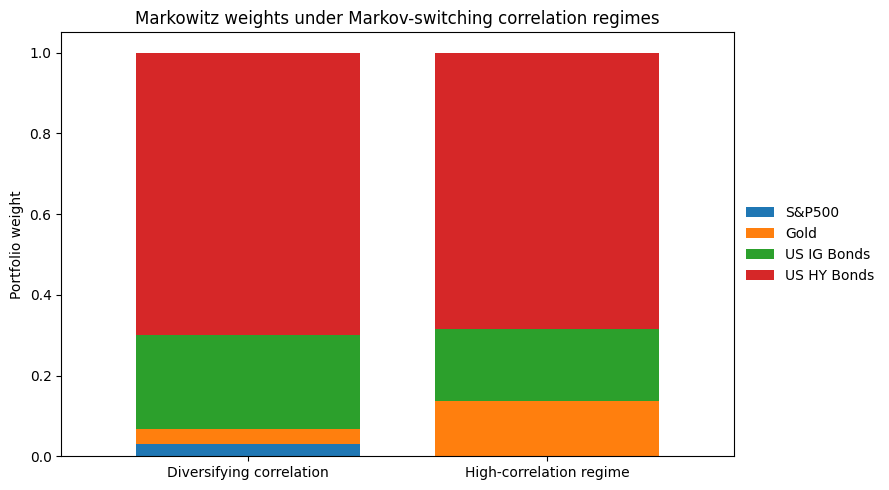

In [11]:
ax = ms_weights.T.plot(kind='bar', stacked=True, figsize=(9, 5), width=0.75)
ax.set_title('Markowitz weights under Markov-switching correlation regimes')
ax.set_ylabel('Portfolio weight')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Figures/application_ms_markowitz_weights.png', dpi=200)
plt.show()

In [12]:
break_weights = pd.DataFrame(index=assets)
all_dates = [weekly_returns.index.min()] + break_dates + [weekly_returns.index.max() + pd.Timedelta(days=1)]

for k in range(len(all_dates) - 1):
    start, end = all_dates[k], all_dates[k + 1]
    r = weekly_returns[(weekly_returns.index >= start) & (weekly_returns.index < end)]
    cov = r.cov() * 52
    name = f'{start.year}-{(end - pd.Timedelta(days=1)).year}'
    break_weights[name] = target_variance_portfolio(cov)

break_weights

,1990-1998,1998-2001,2001-2020,2020-2026
S&P500,0.013,0.015,0.031,0.000
Gold,0.136,0.074,0.081,0.112
US IG Bonds,0.186,0.211,0.217,0.188
US HY Bonds,0.666,0.700,0.671,0.700


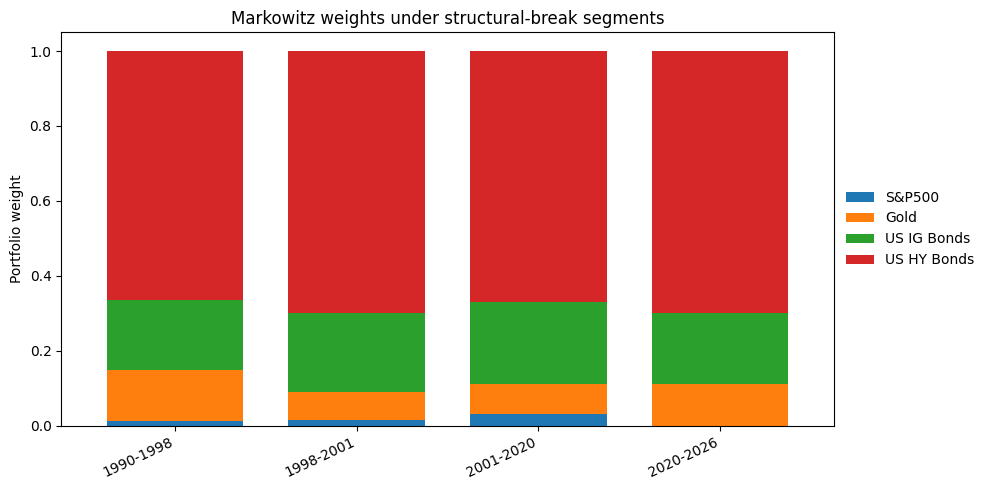

In [13]:
ax = break_weights.T.plot(kind='bar', stacked=True, figsize=(10, 5), width=0.75)
ax.set_title('Markowitz weights under structural-break segments')
ax.set_ylabel('Portfolio weight')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('Figures/application_break_markowitz_weights.png', dpi=200)
plt.show()

## 6. Interpretation

The key empirical message is not that the estimated weights are a production portfolio. The purpose is pedagogical:

- if correlations are unstable, the covariance matrix is not stable;
- if the covariance matrix is not stable, the Markowitz solution is not stable;
- Markov-switching models describe returning regimes;
- structural-break models describe lasting changes in parameters;
- both approaches lead to the same portfolio lesson: diversification is regime-dependent.